# USD/THB Trend, Dollar Index, and Baht Strength Index

This notebook inspects the USD/THB exchange rate trend and puts it in context against two broader currency-strength measures:

- **US Dollar Index (DXY)** — `DX-Y.NYB`, the standard ICE index tracking USD against a basket of major currencies (EUR, JPY, GBP, CAD, SEK, CHF).
- **Baht Strength Index** — there's no widely available public ticker for THB's official trade-weighted index (Bank of Thailand publishes a NEER/REER, but it needs API credentials this project doesn't have configured). Instead, this notebook builds a transparent **equal-weighted proxy** from THB's crosses against three major currencies (EUR, JPY, GBP), normalized so a rising index means baht strength — directly comparable to how DXY is read.

All series load through the `macro_data` package's normal catalog/store (`usd_thb`, `usd_dxy`, `eur_thb`, `jpy_thb`, `gbp_thb` were added to `catalog.yaml`), since each is a single daily value and fits the canonical schema.

Sections:
1. USD/THB trend — moving averages, 52-week range, recent volatility
2. US Dollar Index (DXY) trend
3. Baht Strength Index — methodology and trend
4. Side-by-side comparison and correlation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from macro_data import update, load

pd.set_option("display.max_rows", 20)
%matplotlib inline

update("yahoo")  # refresh usd_thb, usd_dxy, eur_thb, jpy_thb, gbp_thb (incremental)

usd_thb = load("usd_thb")
usd_dxy = load("usd_dxy")
eur_thb = load("eur_thb")
jpy_thb = load("jpy_thb")
gbp_thb = load("gbp_thb")

## 1. USD/THB trend

20/50/200-day moving averages to read the short-, medium-, and long-term trend.

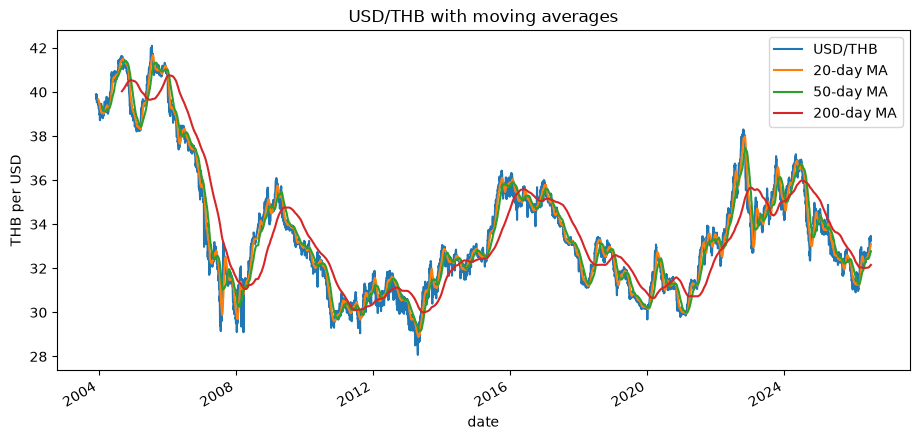

In [2]:
usd_thb_ma = usd_thb.copy()
usd_thb_ma["ma20"] = usd_thb_ma["value"].rolling(20).mean()
usd_thb_ma["ma50"] = usd_thb_ma["value"].rolling(50).mean()
usd_thb_ma["ma200"] = usd_thb_ma["value"].rolling(200).mean()

fig, ax = plt.subplots(figsize=(11, 5))
usd_thb_ma[["value", "ma20", "ma50", "ma200"]].plot(ax=ax, title="USD/THB with moving averages")
ax.set_ylabel("THB per USD")
ax.legend(["USD/THB", "20-day MA", "50-day MA", "200-day MA"])
plt.show()

In [3]:
def trend_summary(df: pd.DataFrame, label: str, unit: str = "") -> pd.Series:
    s = df["value"]
    last_52w = s[s.index >= s.index.max() - pd.Timedelta(days=365)]
    latest = s.iloc[-1]
    daily_returns = s.pct_change().dropna()
    ma50, ma200 = s.rolling(50).mean().iloc[-1], s.rolling(200).mean().iloc[-1]
    return pd.Series(
        {
            "latest": latest,
            "52w_high": last_52w.max(),
            "52w_low": last_52w.min(),
            "pct_from_52w_high": (latest / last_52w.max() - 1) * 100,
            "pct_from_52w_low": (latest / last_52w.min() - 1) * 100,
            "ma50": ma50,
            "ma200": ma200,
            "trend": "bullish (MA50 > MA200)" if ma50 > ma200 else "bearish (MA50 < MA200)",
            "30d_annualized_volatility_pct": daily_returns.tail(30).std() * (252 ** 0.5) * 100,
        },
        name=f"{label} {unit}".strip(),
    )


trend_summary(usd_thb, "USD/THB", "(THB per USD)")

latest                                        33.299999
52w_high                                      33.470001
52w_low                                           30.91
pct_from_52w_high                             -0.507923
pct_from_52w_low                               7.732124
ma50                                           32.77488
ma200                                         32.154715
trend                            bullish (MA50 > MA200)
30d_annualized_volatility_pct                  5.781454
Name: USD/THB (THB per USD), dtype: object

## 2. US Dollar Index (DXY)

The ICE US Dollar Index — a fixed basket weighted toward EUR (~58%), JPY, GBP, CAD, SEK, and CHF. Rising DXY means broad USD strength, not specific to THB.

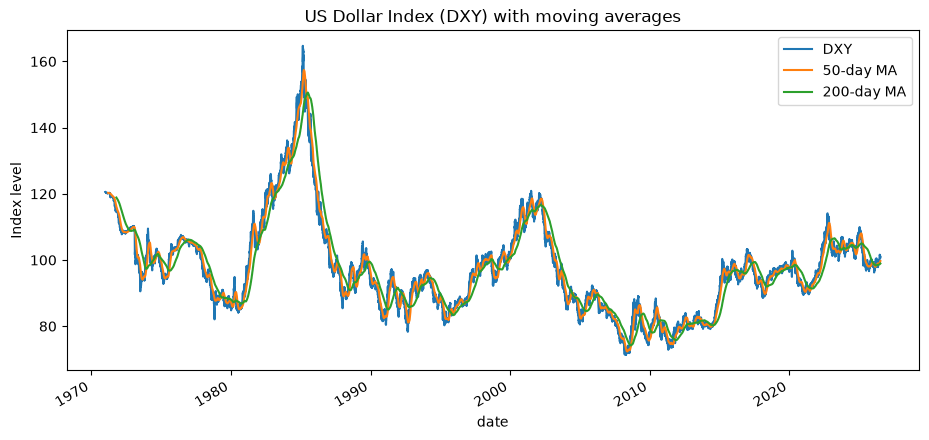

latest                                       100.785004
52w_high                                     101.610001
52w_low                                       96.220001
pct_from_52w_high                             -0.811925
pct_from_52w_low                               4.744338
ma50                                            99.6907
ma200                                         98.937275
trend                            bullish (MA50 > MA200)
30d_annualized_volatility_pct                  4.479064
Name: DXY (index level), dtype: object

In [4]:
usd_dxy_ma = usd_dxy.copy()
usd_dxy_ma["ma50"] = usd_dxy_ma["value"].rolling(50).mean()
usd_dxy_ma["ma200"] = usd_dxy_ma["value"].rolling(200).mean()

fig, ax = plt.subplots(figsize=(11, 5))
usd_dxy_ma[["value", "ma50", "ma200"]].plot(ax=ax, title="US Dollar Index (DXY) with moving averages")
ax.set_ylabel("Index level")
ax.legend(["DXY", "50-day MA", "200-day MA"])
plt.show()

trend_summary(usd_dxy, "DXY", "(index level)")

## 3. Baht Strength Index (proxy)

**Methodology:** each cross (`EUR/THB`, `JPY/THB`, `GBP/THB`) is quoted as THB per unit of foreign currency, so a *falling* cross means the baht buys more of that currency — the baht is *stronger*. For each cross we take the reciprocal (foreign currency per THB), normalize it to 100 at the first date common to all three, and average the three normalized series with equal weights. The result rises when the baht strengthens against this basket — the same reading convention as DXY, so the two can be compared directly.

**Caveats:** this is a simplified equal-weighted proxy over three currencies, not Bank of Thailand's official trade-weighted NEER (which uses ~20+ trading-partner currencies weighted by actual trade share, including CNY — omitted here because Yahoo's `CNYTHB=X` has almost no historical data). Treat the trend direction as informative, not the exact index level.

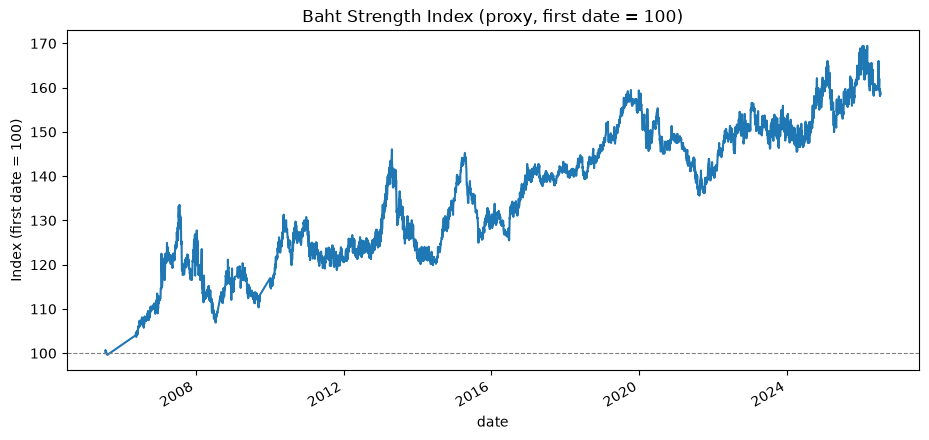

latest                                       159.066864
52w_high                                     169.455624
52w_low                                      154.095749
pct_from_52w_high                             -6.130667
pct_from_52w_low                               3.225991
ma50                                          160.04403
ma200                                         161.97251
trend                            bearish (MA50 < MA200)
30d_annualized_volatility_pct                 14.614992
Name: Baht Strength Index (proxy), dtype: object

In [5]:
crosses = pd.DataFrame(
    {"eur_thb": eur_thb["value"], "jpy_thb": jpy_thb["value"], "gbp_thb": gbp_thb["value"]}
).dropna()

thb_per_unit_inverted = 1 / crosses  # foreign currency per THB: rises when baht strengthens
normalized = thb_per_unit_inverted / thb_per_unit_inverted.iloc[0] * 100
baht_strength_index = normalized.mean(axis=1).rename("value").to_frame()

fig, ax = plt.subplots(figsize=(11, 5))
baht_strength_index["value"].plot(ax=ax, title="Baht Strength Index (proxy, first date = 100)")
ax.set_ylabel("Index (first date = 100)")
ax.axhline(100, color="grey", linewidth=0.8, linestyle="--")
plt.show()

trend_summary(baht_strength_index, "Baht Strength Index", "(proxy)")

## 4. Comparison: DXY vs. Baht Strength Index vs. USD/THB

DXY and the Baht Strength Index share a reading convention (up = that currency stronger), so they're normalized and plotted together first. USD/THB itself is shown separately since a rising USD/THB reflects *both* dollar strength and baht weakness at once — it's the net of the two indices above, not directly comparable on the same normalized scale.

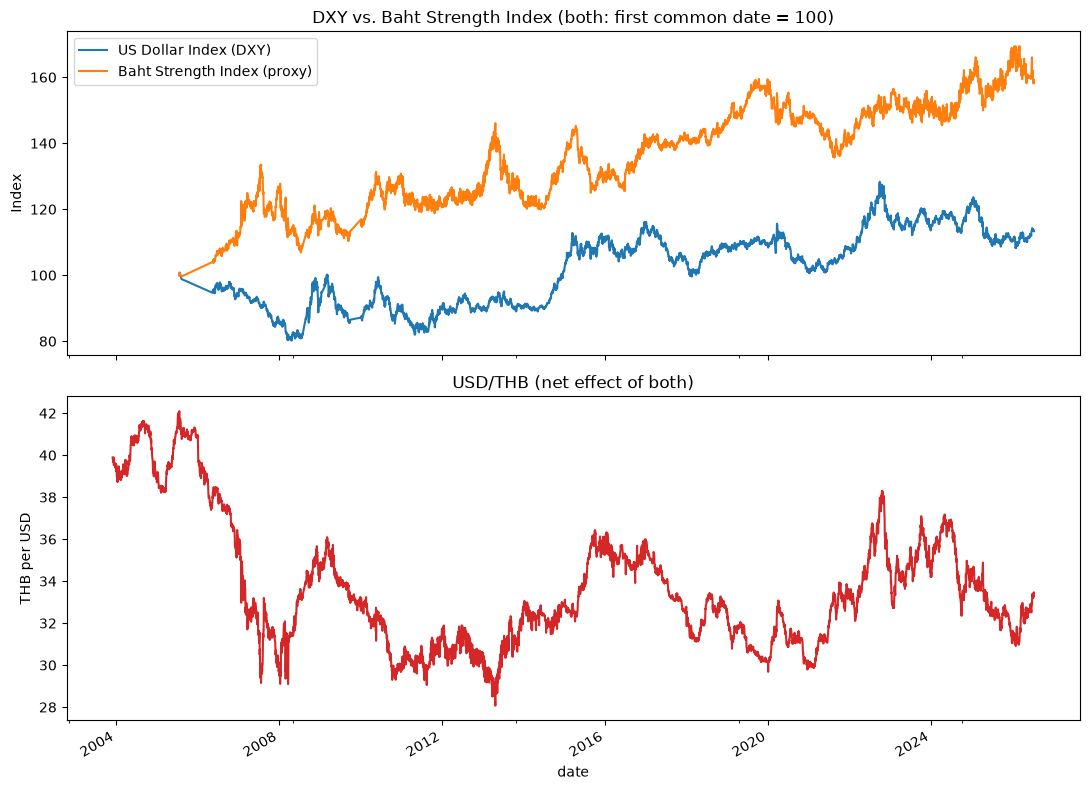

In [6]:
common = pd.DataFrame(
    {"dxy": usd_dxy["value"], "baht_strength": baht_strength_index["value"]}
).dropna()
common_normalized = common / common.iloc[0] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

common_normalized.plot(ax=ax1, title="DXY vs. Baht Strength Index (both: first common date = 100)")
ax1.set_ylabel("Index")
ax1.legend(["US Dollar Index (DXY)", "Baht Strength Index (proxy)"])

usd_thb["value"].plot(ax=ax2, title="USD/THB (net effect of both)", color="tab:red")
ax2.set_ylabel("THB per USD")

plt.tight_layout()
plt.show()

In [7]:
returns = pd.DataFrame(
    {
        "usd_thb": usd_thb["value"],
        "usd_dxy": usd_dxy["value"],
        "baht_strength": baht_strength_index["value"],
    }
).dropna().pct_change().dropna()

returns.corr().round(2)

,usd_thb,usd_dxy,baht_strength
usd_thb,1.00,0.08,-0.52
usd_dxy,0.08,1.00,0.12
baht_strength,-0.52,0.12,1.00
